# Exercise 2: A mixture density network

**Goal.** Learn the posterior $p(\theta \mid x)$ with a neural conditional density estimator $q_\phi(\theta \mid x)$, trained by maximum likelihood on simulated pairs $(\theta, x)$.

This is the same posterior Exercise 1 approximated by rejection, and the same training loop as Exercise 0: trainable parameters, an NLL loss, `Adam`. What changes is that the parameters are now the weights of a small neural network, and the density is a mixture of Gaussians whose parameters depend on $x$.

In [1]:
import math

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import torch
from torch import nn
from sbi.utils import BoxUniform

/opt/miniconda3/envs/road2sbi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The simulator and the observation

This cell is **identical in Exercises 1, 2 and 3**, so results are comparable across notebooks. Feel free to change the constants, but change them in all three notebooks.

- **Prior:** $\theta \sim \mathcal{U}(\theta_{low}, \theta_{high})$.
- **Simulator:** $x = A\sin(\omega\,\theta) + b\,\theta + \varepsilon$, with $\varepsilon \sim \mathcal{N}\big(0, \sigma(\theta)^2\big)$ and $\sigma(\theta) = 1.5\,(\sin\theta + 1.5)$. The noise level itself depends on $\theta$: the noise is *heteroscedastic*.
- **Observation:** `x_obs` is one simulation at `THETA_TRUE`, generated with its own fixed seed so it is the same in every notebook.
- **Reference posterior:** `grid_posterior` computes the exact posterior numerically on a grid. That is only possible because we wrote the simulator and know its likelihood; in real SBI problems you can't. We use it purely as a reference. Set `SHOW_GROUND_TRUTH = False` to hide it from the plots.

In [2]:
# ---------------- Shared setup: identical in exercises 1, 2 and 3 ----------------
SEED = 42
torch.manual_seed(SEED)

# Prior: theta ~ Uniform(THETA_LOW, THETA_HIGH), as a PyTorch distribution -- the same object `sbi` needs in Exercise 3
THETA_LOW, THETA_HIGH = -10.5, 10.5
prior = BoxUniform(low=torch.tensor([THETA_LOW]), high=torch.tensor([THETA_HIGH]))

# Simulator: x = A sin(OMEGA theta) + SLOPE theta + noise, with a theta-dependent noise level
A, OMEGA, SLOPE = 7.0, 0.75, 1.0

def mean_x(theta):
    return A * torch.sin(OMEGA * theta) + SLOPE * theta

def noise_std(theta):
    return 1.5 * (torch.sin(theta) + 1.5)

def simulate(theta):
    """theta: a tensor of any shape. Returns x of the same shape, drawn from the current torch RNG state."""
    theta = torch.as_tensor(theta, dtype=torch.float32)
    return mean_x(theta) + noise_std(theta) * torch.randn_like(theta)

# The observation we do inference on
THETA_TRUE = -1.0
torch.manual_seed(SEED)
x_obs = simulate(torch.tensor(THETA_TRUE)).item()

# Numerical ground-truth posterior on a grid (possible only because we know the likelihood)
SHOW_GROUND_TRUTH = True

def grid_posterior(x, n_grid=2001):
    theta_grid = torch.linspace(THETA_LOW, THETA_HIGH, n_grid)
    log_lik = -0.5 * ((x - mean_x(theta_grid)) / noise_std(theta_grid)) ** 2 - torch.log(noise_std(theta_grid))
    density = torch.exp(log_lik - log_lik.max())
    density = density / (density.sum() * (theta_grid[1] - theta_grid[0]))
    return theta_grid.numpy(), density.numpy()

# Plot colors, consistent across notebooks
COLORS = {"abc": "#E69F00", "mdn": "#009E73", "npe": "#0072B2", "truth": "0.3", "prior": "0.75"}

## Training data

Unlike ABC, we don't simulate for one specific observation. We simulate pairs $(\theta_i, x_i)$ from the prior and the simulator once, and learn $q_\phi(\theta \mid x)$ for all $x$ at the same time.

theta_train_t (5000, 1), x_train_t (5000, 1)


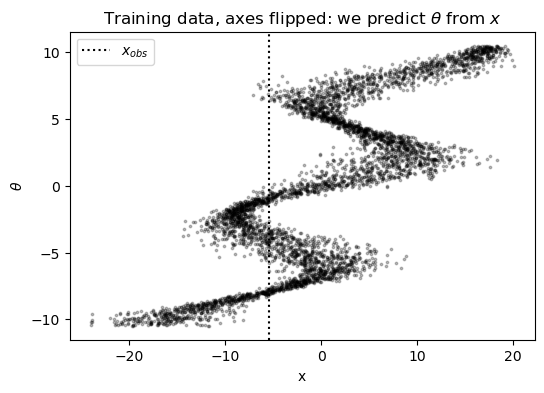

In [3]:
torch.manual_seed(SEED)
N_TRAIN = 5000

theta_train_t = prior.sample((N_TRAIN,))
x_train_t = simulate(theta_train_t)
print(f"theta_train_t {tuple(theta_train_t.shape)}, x_train_t {tuple(x_train_t.shape)}")

plt.figure(figsize=(6, 4))
plt.scatter(x_train_t.numpy(), theta_train_t.numpy(), s=3, c="k", alpha=0.25)
plt.axvline(x_obs, color="k", ls=":", label=r"$x_{obs}$")
plt.xlabel("x")
plt.ylabel(r"$\theta$")
plt.title(r"Training data, axes flipped: we predict $\theta$ from $x$")
plt.legend()
plt.show()

## Warm-up: why a single Gaussian isn't enough

Before building a mixture, try the simplest possible model: a network that predicts one mean $\mu_\phi(x)$, trained with the same Gaussian negative log-likelihood as Exercise 0 but with $\sigma$ fixed at 1. That NLL reduces to $\tfrac12(\theta - \mu_\phi(x))^2$ up to a constant, i.e. ordinary squared-error regression. A single mean can only describe a unimodal $p(\theta \mid x)$, so watch what it does at $x$ values where several branches of the simulator overlap.

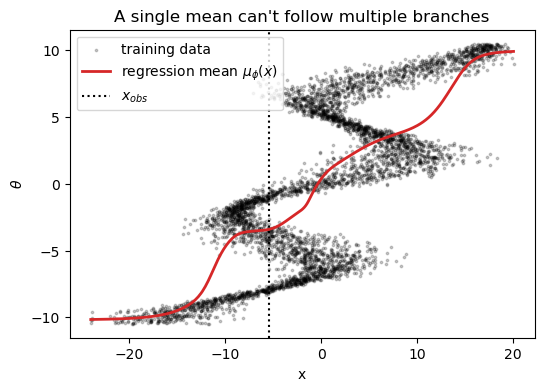

Regression prediction at x_obs: theta = -3.41 (the true posterior has modes near -8, -3.7, -1, and 6.5)


In [4]:
class RegressionNet(nn.Module):
    """Predicts a single mean mu(x). Std is fixed at 1, so training this by Gaussian NLL is just squared-error regression."""

    def __init__(self, n_hidden=64, x_scale=10.0):
        super().__init__()
        self.x_scale = x_scale
        self.mlp = nn.Sequential(
            nn.Linear(1, n_hidden), nn.Tanh(),
            nn.Linear(n_hidden, n_hidden), nn.Tanh(),
            nn.Linear(n_hidden, 1),
        )

    def forward(self, x):
        return self.mlp(x / self.x_scale)

torch.manual_seed(SEED)
baseline = RegressionNet()
optimizer = torch.optim.Adam(baseline.parameters(), lr=3e-3)
for step in range(2000):
    optimizer.zero_grad()
    mu = baseline(x_train_t)
    loss = 0.5 * ((theta_train_t - mu) ** 2).mean()  # Gaussian NLL with sigma fixed at 1, dropping the theta-independent constant
    loss.backward()
    optimizer.step()

x_line = torch.linspace(x_train_t.min(), x_train_t.max(), 300)[:, None]
with torch.no_grad():
    mu_line = baseline(x_line)

plt.figure(figsize=(6, 4))
plt.scatter(x_train_t.numpy(), theta_train_t.numpy(), s=3, c="k", alpha=0.2, label="training data")
plt.plot(x_line.numpy(), mu_line.numpy(), color="C3", lw=2, label=r"regression mean $\mu_\phi(x)$")
plt.axvline(x_obs, color="k", ls=":", label=r"$x_{obs}$")
plt.xlabel("x")
plt.ylabel(r"$\theta$")
plt.title("A single mean can't follow multiple branches")
plt.legend()
plt.show()

with torch.no_grad():
    mu_at_obs = baseline(torch.tensor([[x_obs]])).item()
print(f"Regression prediction at x_obs: theta = {mu_at_obs:.2f} (the true posterior has modes near -8, -3.7, -1, and 6.5)")

## The mixture density network

A mixture density network (MDN) is a neural network that takes $x$ and outputs the parameters of a $K$-component Gaussian mixture over $\theta$:

$$q_\phi(\theta \mid x) = \sum_{k=1}^K \pi_k(x)\,\mathcal{N}\big(\theta \mid \mu_k(x), \sigma_k(x)^2\big)$$

The network has a shared body and three linear output heads, each with $K$ outputs:

- `pi_logits` → mixture weights $\pi_k = \mathrm{softmax}(\text{logits})_k$, which are positive and sum to 1.
- `mu` → component means $\mu_k$.
- `log_sigma` → component log standard deviations. As in Exercise 0, $\sigma_k = e^{\log\sigma_k}$ is always positive.

A single Gaussian ($K = 1$) could not represent a posterior with several peaks. We use $K = 6$, more components than we expect peaks; the network can switch off the ones it doesn't need by giving them small weights.

**Exercise 2a.** Complete the `MDN` module.

In [ ]:
class MDN(nn.Module):
    """Mixture density network: x of shape (batch, 1) -> parameters of a K-component Gaussian mixture over theta."""

    def __init__(self, n_components: int = 6, n_hidden: int = 64, x_scale: float = 10.0):
        super().__init__()
        self.n_components = n_components
        self.x_scale = x_scale  # x spans roughly [-20, 20]; dividing by 10 keeps the tanh units out of saturation

        # EXERCISE 2a (part 1): build the network.
        #   self.mlp: nn.Sequential of Linear(1, n_hidden) -> Tanh -> Linear(n_hidden, n_hidden) -> Tanh
        #   three output heads, each nn.Linear(n_hidden, n_components):
        #   self.logits_head, self.mu_head, self.log_sigma_head
        self.mlp = ...
        self.logits_head = ...
        self.mu_head = ...
        self.log_sigma_head = ...

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Returns (pi_logits, mu, log_sigma), each of shape (batch, n_components)."""
        x_scaled = x / self.x_scale  # keeps the tanh units out of saturation; x spans roughly [-20, 20]
        # EXERCISE 2a (part 2): pass x_scaled through self.mlp, then return the outputs of the three heads.
        h = ...
        return ...

In [ ]:
# Sanity check
test_model = MDN(n_components=6)
pi_logits, mu, log_sigma = test_model(x_train_t[:7])
for name, out in [("pi_logits", pi_logits), ("mu", mu), ("log_sigma", log_sigma)]:
    assert out.shape == (7, 6), f"{name} should have shape (batch, n_components) = (7, 6), got {tuple(out.shape)}"
assert torch.allclose(torch.softmax(pi_logits, dim=-1).sum(-1), torch.ones(7)), "the softmax of the logits should sum to 1"
print("MDN output shapes look right.")

## The loss: negative log-likelihood of a mixture

Same idea as Exercise 0: the mean NLL of the training $\theta$'s, now under the mixture the network predicts from the matching $x$:

$$\text{NLL} = -\frac{1}{B}\sum_{i=1}^{B} \log \sum_{k=1}^{K} \pi_k(x_i)\,\mathcal{N}\big(\theta_i \mid \mu_k(x_i), \sigma_k(x_i)^2\big)$$

Computing $\log \sum_k \exp(\cdot)$ naively is numerically unstable. If every component assigns a tiny density to $\theta_i$, the sum underflows to 0 and its log becomes $-\infty$. Work in log space instead:

$$\log \sum_k \pi_k\,\mathcal{N}_k = \operatorname{logsumexp}_k\big(\log\pi_k + \log\mathcal{N}_k\big)$$

`torch.logsumexp` computes this stably (it factors out the largest term before exponentiating), and `torch.log_softmax` gives $\log\pi_k$ directly from the logits.

**Exercise 2b.** Implement `mdn_nll`.

In [ ]:
def mdn_nll(model: MDN, theta: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """Mean negative log-likelihood of theta (batch, 1) under the mixture the model predicts from x (batch, 1)."""
    # EXERCISE 2b:
    #   1. Get (pi_logits, mu, log_sigma) from the model; each has shape (batch, K).
    #   2. log_pi = torch.log_softmax(pi_logits, dim=-1)
    #   3. Per-component Gaussian log density of theta, shape (batch, K):
    #      -0.5 * ((theta - mu) / sigma)^2 - log_sigma - 0.5 * log(2 pi)
    #      (theta has shape (batch, 1) and broadcasts against (batch, K))
    #   4. Combine them with torch.logsumexp over the component dimension, and return minus the mean.
    pi_logits, mu, log_sigma = ...
    log_pi = ...
    log_normal = ...
    return ...

In [ ]:
# Sanity check against torch.distributions
theta_b, x_b = theta_train_t[:16], x_train_t[:16]
with torch.no_grad():
    pi_logits, mu, log_sigma = test_model(x_b)
    mixture = torch.distributions.MixtureSameFamily(
        torch.distributions.Categorical(logits=pi_logits),
        torch.distributions.Normal(mu, log_sigma.exp()),
    )
    expected = -mixture.log_prob(theta_b.squeeze(-1)).mean()
    assert torch.allclose(mdn_nll(test_model, theta_b, x_b), expected, atol=1e-4)
print("mdn_nll matches torch.distributions.MixtureSameFamily.")

## Training

This is the loop from Exercise 0d, unchanged except for the parameters and the loss: `mdn.parameters()` instead of `[mu, log_sigma]`, and `mdn_nll` instead of `gaussian_nll`. For simplicity, every step uses the full training set.

**Exercise 2c.** Write the training loop.

In [ ]:
torch.manual_seed(SEED)
mdn = MDN(n_components=6)
optimizer = torch.optim.Adam(mdn.parameters(), lr=3e-3)

n_steps = 3000
losses = []

for step in range(n_steps):
    # EXERCISE 2c: the same four steps as Exercise 0d, with loss = mdn_nll(mdn, theta_train_t, x_train_t).
    ...  # zero_grad
    loss = ...  # mdn_nll(mdn, theta_train_t, x_train_t)
    ...  # loss.backward()
    ...  # optimizer.step()
    losses.append(loss.item())

plt.plot(losses)
plt.xlabel("step")
plt.ylabel("NLL")
plt.title("MDN training loss")
plt.show()

## The posterior at $x_{obs}$

Once trained, the MDN gives the density $q_\phi(\theta \mid x)$ for any $x$ with a single forward pass.

**Exercise 2d.** Implement `mdn_density`: evaluate the mixture density for one value of `x` on a grid of `theta` values.

In [ ]:
def mdn_density(model: MDN, x: float, theta_grid: np.ndarray) -> np.ndarray:
    """Density q(theta | x) at every value in theta_grid, for a single scalar x. Returns a numpy array."""
    with torch.no_grad():
        # EXERCISE 2d:
        #   1. Turn x into a (1, 1) float32 tensor, and theta_grid into a (n_grid, 1) float32 tensor.
        #   2. Get the mixture parameters from the model; each has shape (1, K) and broadcasts against (n_grid, 1).
        #   3. Compute log pi + log N(theta | mu, sigma^2) for every grid point and component, shape (n_grid, K),
        #      take the logsumexp over components, and return the exponentiated result as a numpy array.
        x_t = ...
        theta_t = ...
        pi_logits, mu, log_sigma = ...
        log_pi = ...
        log_normal = ...
        return ...

In [ ]:
# Sanity check: a density should integrate to 1 (the grid is wider than the prior, since the MDN is not truncated)
wide_grid = np.linspace(-30, 30, 6001)
density = mdn_density(mdn, x_obs, wide_grid)
assert density.shape == wide_grid.shape, "return one density value per grid point"
mass = density.sum() * (wide_grid[1] - wide_grid[0])
assert abs(mass - 1) < 1e-2, f"the density should integrate to 1, got {mass:.3f}"
print(f"mdn_density integrates to {mass:.4f}.")

### Comparison with rejection ABC

Rerun the rejection ABC from Exercise 1 (its implementation is provided below) with the same settings, and compare.

In [ ]:
def rejection_abc(x_obs, epsilon, n_simulations):
    """Rejection ABC, from Exercise 1."""
    theta = prior.sample((n_simulations,)).squeeze(-1)
    x_sim = simulate(theta)
    return theta[torch.abs(x_sim - x_obs) < epsilon].numpy()

EPSILON, N_SIMULATIONS = 0.15, 100_000
abc_posterior_samples = rejection_abc(x_obs, EPSILON, N_SIMULATIONS)

theta_grid = np.linspace(THETA_LOW, THETA_HIGH, 1000)
mdn_posterior_density = mdn_density(mdn, x_obs, theta_grid)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(abc_posterior_samples, bins=60, range=(THETA_LOW, THETA_HIGH), density=True,
        color=COLORS["abc"], alpha=0.5, label=rf"ABC ($\epsilon$ = {EPSILON})")
ax.plot(theta_grid, mdn_posterior_density, color=COLORS["mdn"], lw=2.5, label="MDN")
if SHOW_GROUND_TRUTH:
    ax.plot(*grid_posterior(x_obs), color=COLORS["truth"], lw=1.5, ls="--", label="true posterior (grid)")
ax.axvline(THETA_TRUE, color="k", ls="--", lw=1, label=r"$\theta_{true}$")
ax.set(xlabel=r"$\theta$", ylabel="density", title=r"Posterior at $x_{obs}$")
ax.legend(fontsize=8)
plt.show()

**Check:** does the MDN find the same number of peaks, in the same places, as the ABC histogram? Are their relative heights similar? If not, try training for longer or changing `n_components`.

### Amortization: new observations for free

ABC had to simulate from scratch for $x_{obs}$. The MDN has learned $q_\phi(\theta \mid x)$ for every $x$ in the range of the training data at once, so a new observation costs a single forward pass.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharex=True)
for ax, x_new in zip(axes, [-12.0, 0.0, 10.0]):
    ax.plot(theta_grid, mdn_density(mdn, x_new, theta_grid), color=COLORS["mdn"], lw=2, label="MDN")
    if SHOW_GROUND_TRUTH:
        ax.plot(*grid_posterior(x_new), color=COLORS["truth"], lw=1.5, ls="--", label="true posterior (grid)")
    ax.set(xlabel=r"$\theta$", title=f"x = {x_new}")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
x_line = torch.linspace(x_train_t.min(), x_train_t.max(), 300)[:, None]
with torch.no_grad():
    pi_logits_grid, mu_grid, log_sigma_grid = mdn(x_line)
sigma_grid = torch.exp(log_sigma_grid)
weights_grid = torch.softmax(pi_logits_grid, dim=-1)
x_np = x_line.numpy().ravel()

# Rescale so the dominant component at each x has alpha = 1; the rest fade out.
alpha_grid = (weights_grid / weights_grid.max(dim=-1, keepdim=True).values).numpy()
component_colors = plt.cm.tab10(np.linspace(0, 1, mdn.n_components))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_train_t.numpy(), theta_train_t.numpy(), s=3, c="k", alpha=0.15, label="training data")
for k in range(mdn.n_components):
    mu_k = mu_grid[:, k].numpy()
    sigma_k = sigma_grid[:, k].numpy()
    alpha_k = alpha_grid[:, k]
    color = component_colors[k]

    # Mean line: one color per component, per-segment alpha from the mixture weight.
    points = np.array([x_np, mu_k]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    seg_alpha = (alpha_k[:-1] + alpha_k[1:]) / 2
    seg_colors = np.tile(color, (len(seg_alpha), 1))
    seg_colors[:, 3] = seg_alpha
    ax.add_collection(LineCollection(segments, colors=seg_colors, linewidths=2))

    # +-1 sigma band, same per-segment alpha (scaled down so it stays a band, not a line).
    for i in range(len(x_np) - 1):
        ax.fill_between(x_np[i:i + 2], (mu_k - sigma_k)[i:i + 2], (mu_k + sigma_k)[i:i + 2],
                         color=color, alpha=0.3 * seg_alpha[i], linewidth=0)

    ax.plot([], [], color=color, lw=2, label=f"component {k}: $\\mu_{k}(x)$")  # solid legend swatch

ax.axvline(x_obs, color="k", ls=":", label=r"$x_{obs}$")
ax.autoscale_view()
ax.set_xlabel("x")
ax.set_ylabel(r"$\theta$")
ax.set_title(r"MDN components, shaded by mixture weight $\pi_k(x)$")
ax.legend(fontsize=7, ncol=2, loc="upper left")
plt.show()

## Questions to think about

1. Retrain with `n_components=1`. What does the posterior look like now, and how does that relate to fitting a single Gaussian in Exercise 0?
2. Why is this approach called *amortized*, compared to Exercise 1? When does the upfront cost of training pay off?
3. We trained on 5,000 simulations. For which values of $x$ would you expect the MDN to be least reliable, and why? (Hint: look at the training data plot.)
4. What would you need to change to handle a 2D parameter $\theta$, or a 100-dimensional observation $x$ such as a time series?
5. The MDN gives you the posterior density $q_\phi(\theta \mid x)$ directly, evaluated at a point -- unlike Exercise 3's NPE, which you sample from with `posterior.sample(...)`. How would you draw samples from the Gaussian mixture $q_\phi(\theta \mid x_{obs})$ predicted above, instead of just evaluating its density on a grid?